# 📘 NLP Foundations – Text as Data  
## TOPS Technologies Assessment Notebook

**Dataset:** Amazon Reviews (`bittlingmayer/amazonreviews`)  
**Goal:** Run the notebook from top to bottom with **Run All** in VS Code Jupyter or Jupyter Notebook.

This notebook is designed to:
- install dependencies automatically,
- authenticate with Kaggle automatically when credentials are available,
- download and extract the dataset,
- answer the concept questions,
- complete the practical tasks,
- build the mini-project pipeline,
- and generate professional plots and summaries.

## Table of Contents

1. Objective  
2. Dataset Overview  
3. Environment Setup  
4. Kaggle Auto-Download  
5. Data Loading  
6. Exploratory Data Analysis  
7. NLP Preprocessing  
8. Section A — Concept Application  
9. Section B — Practical Tasks  
10. Section C — Mini Project  
11. Final Insights

## 1) Objective

This notebook treats text as data and demonstrates a complete NLP workflow on Amazon Reviews:
- structural profiling,
- regex-based tokenization,
- n-gram analysis,
- Zipf’s Law validation,
- and data-quality auditing.

The notebook is written to be modular, readable, and executable end-to-end.

## 2) Dataset Overview

The assessment uses the Amazon Reviews dataset from Kaggle:

`https://www.kaggle.com/datasets/bittlingmayer/amazonreviews`

The notebook is built to handle common Kaggle dataset formats:
- `.txt`
- `.csv`
- `.json`
- `.jsonl`

It automatically searches the extracted folder and loads the review text robustly.

## 3) Kaggle setup instructions

To enable automatic download, place your Kaggle credentials in one of these ways:

**Option A — `kaggle.json`**
- Windows: `C:\Users\<YOU>\.kaggle\kaggle.json`
- Linux/macOS: `~/.kaggle/kaggle.json`

**Option B — Environment variables**
- `KAGGLE_USERNAME`
- `KAGGLE_KEY`

If credentials are missing, the notebook will skip download gracefully and continue with any already extracted local data.

In [14]:
# ------------------------------------------------------------
# 4) Automatic dependency installation
# ------------------------------------------------------------
import sys
import subprocess
import importlib.util


def ensure_package(pkg_name: str, import_name: str | None = None):
    import_name = import_name or pkg_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pkg_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_name])


required_packages = [
    ("pandas", None),
    ("numpy", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("plotly", None),
    ("nltk", None),
    ("wordcloud", None),
    ("kaggle", None),
    ("scikit-learn", "sklearn"),
    ("networkx", None),
    ("beautifulsoup4", "bs4"),
]

for pkg, imp in required_packages:
    ensure_package(pkg, imp)

print("All required packages are available.")

All required packages are available.


In [15]:
# ------------------------------------------------------------
# 5) Imports and global configuration
# ------------------------------------------------------------
import os
import re
import json
import math
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from IPython.display import display, Markdown, HTML

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "amazonreviews"
EXTRACT_DIR = DATA_DIR / "amazonreviews_extracted"
ARTIFACT_DIR = Path("./artifacts")
for folder in [DATA_DIR, RAW_DIR, EXTRACT_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Artifact directory: {ARTIFACT_DIR.resolve()}")

Data directory: C:\Users\harshil patel\Downloads\data
Artifact directory: C:\Users\harshil patel\Downloads\artifacts


In [16]:
# ------------------------------------------------------------
# Kaggle API Setup using Environment Variables
# ------------------------------------------------------------

import os
import json
from pathlib import Path

# Your Kaggle credentials
os.environ["KAGGLE_USERNAME"] = "YOUR_KAGGLE_USERNAME"
os.environ["KAGGLE_KEY"] = "KGAT_ed82f68afae5304d4f58b3d94e44dfb6"

# Create .kaggle directory
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)

# Create kaggle.json automatically
kaggle_json_path = kaggle_dir / "kaggle.json"

with open(kaggle_json_path, "w") as f:
    json.dump({
        "username": os.environ["KAGGLE_USERNAME"],
        "key": os.environ["KAGGLE_KEY"]
    }, f)

try:
    os.chmod(kaggle_json_path, 0o600)
except:
    pass

print("Kaggle credentials configured successfully.")

Kaggle credentials configured successfully.


In [17]:
# ------------------------------------------------------------
# Dataset Download
# ------------------------------------------------------------

from kaggle.api.kaggle_api_extended import KaggleApi

DATASET_SLUG = "bittlingmayer/amazonreviews"

api = KaggleApi()
api.authenticate()

print("Downloading dataset...")

api.dataset_download_files(
    DATASET_SLUG,
    path="./data",
    unzip=True,
    quiet=False
)

print("Dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/bittlingmayer/amazonreviews


100%|██████████| 493M/493M [00:01<00:00, 352MB/s] 

Dataset downloaded successfully.


In [24]:
from pathlib import Path

for file in Path("./data").rglob("*"):
    print(file)

data\amazonreviews
data\amazonreviews_extracted
data\test.ft.txt.bz2
data\train.ft.txt.bz2


In [26]:
# ------------------------------------------------------------
# Extract .bz2 Amazon Review Files
# ------------------------------------------------------------

import bz2
import shutil
from pathlib import Path

DATA_PATH = Path("./data")

bz2_files = list(DATA_PATH.glob("*.bz2"))

print("BZ2 Files Found:\n")

for file in bz2_files:
    print(file)

for bz2_file in bz2_files:

    output_file = bz2_file.with_suffix("")

    # Skip if already extracted
    if output_file.exists():
        print(f"\nAlready extracted: {output_file.name}")
        continue

    print(f"\nExtracting: {bz2_file.name}")

    with bz2.BZ2File(bz2_file, 'rb') as fr:
        with open(output_file, 'wb') as fw:
            shutil.copyfileobj(fr, fw)

    print(f"Extracted -> {output_file.name}")

print("\nExtraction completed.")

BZ2 Files Found:

data\test.ft.txt.bz2
data\train.ft.txt.bz2

Extracting: test.ft.txt.bz2
Extracted -> test.ft.txt

Extracting: train.ft.txt.bz2
Extracted -> train.ft.txt

Extraction completed.


In [27]:
# ------------------------------------------------------------
# 7) Locate and Load Amazon Reviews Dataset Correctly
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd

DATA_PATH = Path("./data")

# Find all txt/csv/json files
all_files = []

for ext in ["*.txt", "*.csv", "*.json", "*.jsonl"]:
    all_files.extend(DATA_PATH.rglob(ext))

print("Files Found:\n")

for f in all_files:
    print(f)

# ------------------------------------------------------------
# Parse FastText format
# ------------------------------------------------------------

def parse_fasttext_line(line):

    line = line.strip()

    if not line:
        return None

    if line.startswith("__label__"):

        parts = line.split(maxsplit=1)

        label = parts[0].replace("__label__", "")

        text = parts[1] if len(parts) > 1 else ""

        return {
            "label": label,
            "text": text
        }

    return {
        "label": "unknown",
        "text": line
    }


# ------------------------------------------------------------
# Load txt files
# ------------------------------------------------------------

def load_fasttext_file(file_path, max_rows=50000):

    rows = []

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:

        for i, line in enumerate(f):

            if i >= max_rows:
                break

            parsed = parse_fasttext_line(line)

            if parsed:
                rows.append(parsed)

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Automatically detect dataset file
# ------------------------------------------------------------

dataset_frames = []

for file in all_files:

    try:

        if file.suffix == ".txt":

            print(f"\nLoading: {file.name}")

            temp_df = load_fasttext_file(file)

            temp_df["source_file"] = file.name

            dataset_frames.append(temp_df)

    except Exception as e:

        print(f"Error loading {file.name}: {e}")


# ------------------------------------------------------------
# Combine all files
# ------------------------------------------------------------

if dataset_frames:

    df = pd.concat(dataset_frames, ignore_index=True)

    df = df.dropna(subset=["text"])

    df = df.drop_duplicates(subset=["text"])

    df["text"] = df["text"].astype(str)

    df["label"] = df["label"].astype(str)

    print("\nDataset Loaded Successfully!")

    print(f"Total Rows: {len(df):,}")

    display(df.head())

else:

    print("No dataset files found.")

Files Found:

data\test.ft.txt
data\train.ft.txt

Loading: test.ft.txt

Loading: train.ft.txt

Dataset Loaded Successfully!
Total Rows: 100,000


,label,text,source_file
0,2,Great CD: My lovely Pat has one of the GREAT v...,test.ft.txt
1,2,One of the best game music soundtracks - for a...,test.ft.txt
2,1,Batteries died within a year ...: I bought thi...,test.ft.txt
3,2,"works fine, but Maha Energy is better: Check o...",test.ft.txt
4,2,Great for the non-audiophile: Reviewed quite a...,test.ft.txt


,label,char_count,word_count,avg_word_length
count,100000,100000.000000,100000.00000,100000.000000
unique,2,NaN,NaN,NaN
top,2,NaN,NaN,NaN
freq,50880,NaN,NaN,NaN
mean,NaN,440.598860,80.05653,4.203669
std,NaN,240.379924,43.28544,0.403958
min,NaN,101.000000,12.00000,2.354839
25%,NaN,237.000000,44.00000,3.931818
50%,NaN,394.000000,72.00000,4.171053
75%,NaN,609.000000,111.00000,4.438356


Labels: {'2': 50880, '1': 49120}


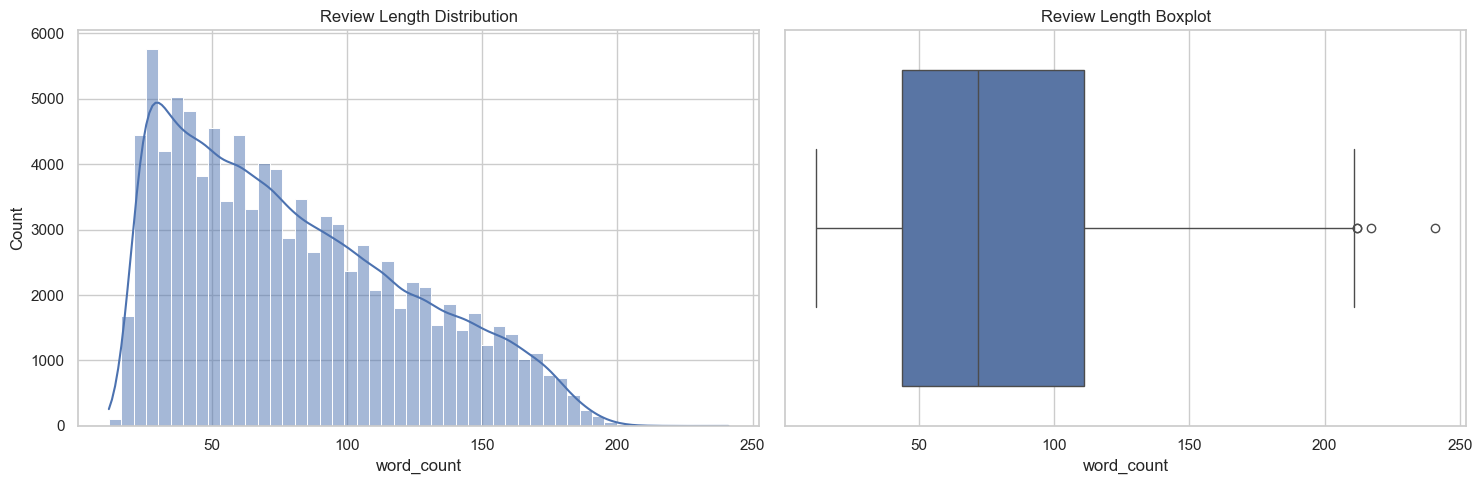

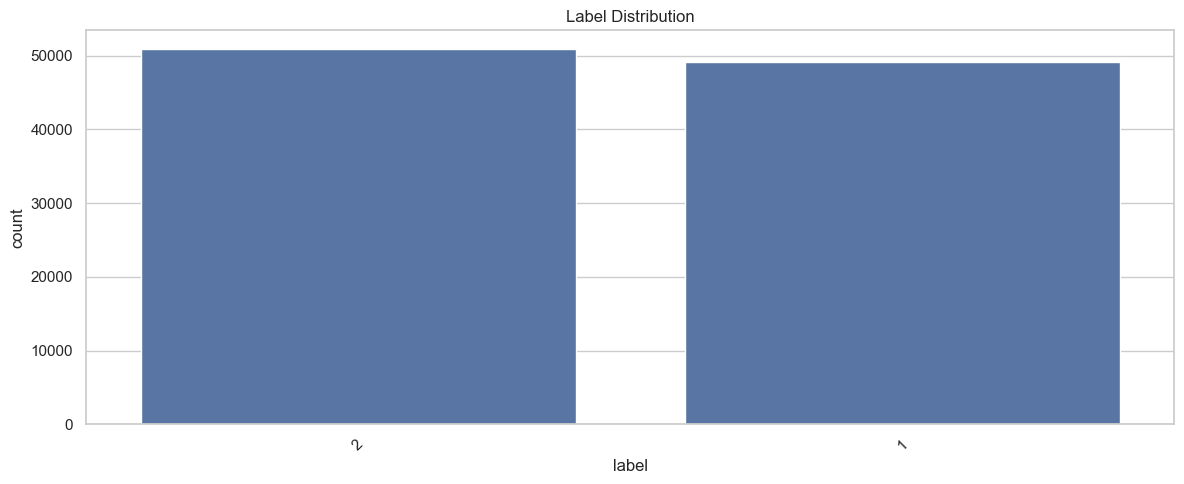

In [28]:
# ------------------------------------------------------------
# 8) Basic exploratory data analysis
# ------------------------------------------------------------
def basic_text_stats(frame: pd.DataFrame):
    temp = frame.copy()
    temp["char_count"] = temp["text"].str.len()
    temp["word_count"] = temp["text"].str.split().str.len()
    temp["sentence_count"] = temp["text"].str.count(r"[.!?]+").clip(lower=1)
    temp["avg_word_length"] = temp["text"].apply(lambda x: np.mean([len(w) for w in re.findall(r"\b\w+\b", x)]) if re.findall(r"\b\w+\b", x) else 0)
    return temp


df = basic_text_stats(df)

if not df.empty:
    display(df[["label", "char_count", "word_count", "avg_word_length"]].describe(include="all"))
    print("Labels:", df["label"].value_counts().head(10).to_dict())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[0])
    axes[0].set_title("Review Length Distribution")
    sns.boxplot(x=df["word_count"], ax=axes[1])
    axes[1].set_title("Review Length Boxplot")
    plt.tight_layout()
    plt.show()

    if df["label"].nunique() > 1:
        plt.figure(figsize=(12, 5))
        sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
        plt.title("Label Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [29]:
# ------------------------------------------------------------
# 9) Cleaning and tokenization helpers
# ------------------------------------------------------------
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not", "'re": " are", "'s": " is",
    "'d": " would", "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
}


def expand_contractions(text: str) -> str:
    for k, v in CONTRACTIONS.items():
        text = re.sub(k, v, text, flags=re.IGNORECASE)
    return text


def clean_text(text: str) -> str:
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = expand_contractions(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def remove_noise(text: str) -> str:
    text = clean_text(text)
    text = re.sub(r"[^a-z0-9\s\.\,\!\?\$\€\£\%\-\+\/]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Tokenizer designed to capture specs, units, model numbers, currency, and general words.
TOKEN_PATTERN = re.compile(r"""
    \$\d+(?:\.\d+)? |
    \b\d+(?:\.\d+)?(?:gb|tb|mb|hz|khz|mhz|ghz|w|v|mah|mAh|inch|in|cm|mm|kg|g|mp|fps|x)\b |
    \b[a-zA-Z]+-\d+[a-zA-Z0-9-]*\b |
    \b\d+[a-zA-Z]+\b |
    \b[a-zA-Z]+\d+[a-zA-Z0-9-]*\b |
    \b[a-zA-Z]{2,}(?:'[a-z]+)?\b |
    [\!\?\$\%\&\#\+\-/]
""", re.VERBOSE)


def regex_tokenize(text: str):
    text = clean_text(text)
    return TOKEN_PATTERN.findall(text)


sample_text = df["text"].iloc[0] if not df.empty else "The laptop costs $299 and has 16GB RAM, i7-12700H CPU, 120Hz display, and USB-C charging."
print("Original:", sample_text[:300])
print("Tokens:", regex_tokenize(sample_text)[:40])

Original: Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kil
Tokens: ['great', 'cd', 'my', 'lovely', 'pat', 'has', 'one', 'of', 'the', 'great', 'voices', 'of', 'her', 'generation', 'have', 'listened', 'to', 'this', 'cd', 'for', 'years', 'and', 'still', 'love', 'it', 'when', 'am', 'in', 'good', 'mood', 'it', 'makes', 'me', 'feel', 'better', 'bad', 'mood', 'just', 'evaporates', 'like']


## 10) Section A — Concept Application

The following answers are written directly in the notebook so the assessment can be reviewed easily.

In [30]:
concept_answers = {
    1: (
        "Text is considered unstructured data because it does not follow a fixed row-column schema like tabular data. "
        "Words, punctuation, slang, emojis, and grammar appear in flexible forms, so the meaning must be extracted through NLP preprocessing."
    ),
    2: (
        "A corpus is a collection of text documents used for analysis in NLP. In this notebook, the Amazon reviews together form the corpus."
    ),
    3: (
        "Frequent words such as 'the', 'a', and 'is' are usually stopwords. They appear often but carry little sentiment meaning, so they are typically removed or down-weighted before sentiment analysis."
    ),
    4: (
        "A standard NLP pipeline usually follows: text acquisition → cleaning → tokenization → normalization → stopword handling → feature extraction → modeling → evaluation."
    ),
    5: (
        "URLs, emojis, symbols, and other noisy patterns are handled during the text cleaning / preprocessing stage, before feature extraction."
    )
}
for k, v in concept_answers.items():
    display(Markdown(f"**Q{k}.** {v}"))

**Q1.** Text is considered unstructured data because it does not follow a fixed row-column schema like tabular data. Words, punctuation, slang, emojis, and grammar appear in flexible forms, so the meaning must be extracted through NLP preprocessing.

**Q2.** A corpus is a collection of text documents used for analysis in NLP. In this notebook, the Amazon reviews together form the corpus.

**Q3.** Frequent words such as 'the', 'a', and 'is' are usually stopwords. They appear often but carry little sentiment meaning, so they are typically removed or down-weighted before sentiment analysis.

**Q4.** A standard NLP pipeline usually follows: text acquisition → cleaning → tokenization → normalization → stopword handling → feature extraction → modeling → evaluation.

**Q5.** URLs, emojis, symbols, and other noisy patterns are handled during the text cleaning / preprocessing stage, before feature extraction.

## 11) Section B — Practical Task 1: Custom Regex Tokenizer

In [31]:
# Demonstration on selected sample reviews
if not df.empty:
    demo_reviews = df["text"].sample(min(5, len(df)), random_state=42).tolist()
else:
    demo_reviews = [
        "The laptop costs $299 and has 16GB RAM, i7-12700H CPU, 120Hz display, and USB-C charging.",
        "Great sound quality! Battery lasts 10hrs, Bluetooth 5.2, and 4K playback.",
    ]

for i, review in enumerate(demo_reviews, 1):
    tokens = regex_tokenize(review)
    display(Markdown(f"**Sample review {i}:** {review}"))
    display(Markdown(f"**Regex tokens:** `{tokens[:40]}`"))

**Sample review 1:** Best... to good: At first I didn't mlike cats a lot. But when I read this book I turned into a cat lover. This was my favorite book until I read the second and third book. Those are way better. If this is going to be your first time reading this book. READ IT!!Here is a super short summary of what happens: A house cat named Rusty turns into Firepaw because he joins Thunderclan (from the forest) and he turns into an apprentice and has bad luck and very good luck.

**Regex tokens:** `['best', 'to', 'good', 'at', 'first', 'did', 'not', 'mlike', 'cats', 'lot', 'but', 'when', 'read', 'this', 'book', 'turned', 'into', 'cat', 'lover', 'this', 'was', 'my', 'favorite', 'book', 'until', 'read', 'the', 'second', 'and', 'third', 'book', 'those', 'are', 'way', 'better', 'if', 'this', 'is', 'going', 'to']`

**Sample review 2:** Ugly Video, Missing Sound Effects and Skips: A Rip-off!: I hope this review gets posted in time to warn fans of the original release to AVOID this copy. My college-age sons and I have been Hobbit fans since their toddler days when watched our original VHS tape until they had it memorized (dialog, songs and sound effects) and our tape disintegrated.Seeing Peter Jackson's version made us remember the simple joys of watching the Rankin & Bass production together in our younger days.I purchased this VHS thinking that it was going to be like our tape of old, you know, with a watchable picture, clear sound, wonderful sound effects.This version is a mess. The picture was dark and murky. Several skips interrupted what could be seen. Worst of all, the wonderful sound effects that enriched the key scenes in the story are missing from this VHS tape.Pleas, DO NOT WASTE YOUR MONEY on this miserable copy!

**Regex tokens:** `['ugly', 'video', 'missing', 'sound', 'effects', 'and', 'skips', 'rip', '-', 'off', '!', 'hope', 'this', 'review', 'gets', 'posted', 'in', 'time', 'to', 'warn', 'fans', 'of', 'the', 'original', 'release', 'to', 'avoid', 'this', 'copy', 'my', 'college', '-', 'age', 'sons', 'and', 'have', 'been', 'hobbit', 'fans', 'since']`

**Sample review 3:** Buy it used, or save your money....: I only wish this were the masterpiece it could have been. A nice mastering of the original tapes would have been far, far better than this slightly thin re-recording of the originals. As another reviewer mentioned, the sound is far too clean as compared with the nice warm analog sound of the originals. The instrumentations are well done, but generally lacking any warmth or personality.Yes, I know many of you think that Wilson could gargle on tape and it would be a masterpiece, but his voice here does not compare with the originals, nor do you get the rest of the BBs. His voice here, as with the Pet Sounds Live, is sort of flat. It is better than on Pet Sounds Live, but still not where it needed to be to undertake this monster of a job.Basically, it is ok, but wait for a used copy and pick that up. You will undoubtedly spend more time listening to the more cohesive bootlegs than to this recording.

**Regex tokens:** `['buy', 'it', 'used', 'or', 'save', 'your', 'money', 'only', 'wish', 'this', 'were', 'the', 'masterpiece', 'it', 'could', 'have', 'been', 'nice', 'mastering', 'of', 'the', 'original', 'tapes', 'would', 'have', 'been', 'far', 'far', 'better', 'than', 'this', 'slightly', 'thin', 're', '-', 'recording', 'of', 'the', 'originals', 'as']`

**Sample review 4:** Terrible: The only reason I gave this movie two stars is because they spent so much money on special effects that I felt bad just giving it one. This movie is absolutely the worst film I've seen this year. Unless of course you're into weak characters, stupid one liners, and a wise cracking kid that gets more annoying by the minute. It's predictable, and not worth the energy spent sitting through it.

**Regex tokens:** `['terrible', 'the', 'only', 'reason', 'gave', 'this', 'movie', 'two', 'stars', 'is', 'because', 'they', 'spent', 'so', 'much', 'money', 'on', 'special', 'effects', 'that', 'felt', 'bad', 'just', 'giving', 'it', 'one', 'this', 'movie', 'is', 'absolutely', 'the', 'worst', 'film', 'have', 'seen', 'this', 'year', 'unless', 'of', 'course']`

**Sample review 5:** Worthless book to prep from: I bought this book last year to prepare for my exam April 2011. I studied this book cover to cover and took both the practice exams. However, this books cover absolutely nothing that you might see on the FE chemical exam. It doesn't do a good job to cover fluids which apparently is a big part of chemical evening exam. Coverage of reaction engineering is bare minimum at best. Process control is covered much better but that is only 5% of the exam. Process optimization is not covered that well either. All in all this book is pretty much a waste of money if you want to prep for the evening exam.

**Regex tokens:** `['worthless', 'book', 'to', 'prep', 'from', 'bought', 'this', 'book', 'last', 'year', 'to', 'prepare', 'for', 'my', 'exam', 'april', 'studied', 'this', 'book', 'cover', 'to', 'cover', 'and', 'took', 'both', 'the', 'practice', 'exams', 'however', 'this', 'books', 'cover', 'absolutely', 'nothing', 'that', 'you', 'might', 'see', 'on', 'the']`

### Regex Tokenizer Notes

The tokenizer is designed to retain:
- currency amounts like `$299`
- technical units like `16GB`, `120Hz`
- model patterns like `i7-12700H`
- general word tokens
- symbolic tokens that may matter in product reviews

## 12) Section B — Practical Task 2: N-Gram Analysis

**Top 1-grams**

,ngram,count
0,!,91748
225,-,68196
5654,book,62133
20002,great,30293
26538,like,30247
19670,good,29795
30000,movie,28823
24911,just,26840
36870,read,25714
643,?,20210


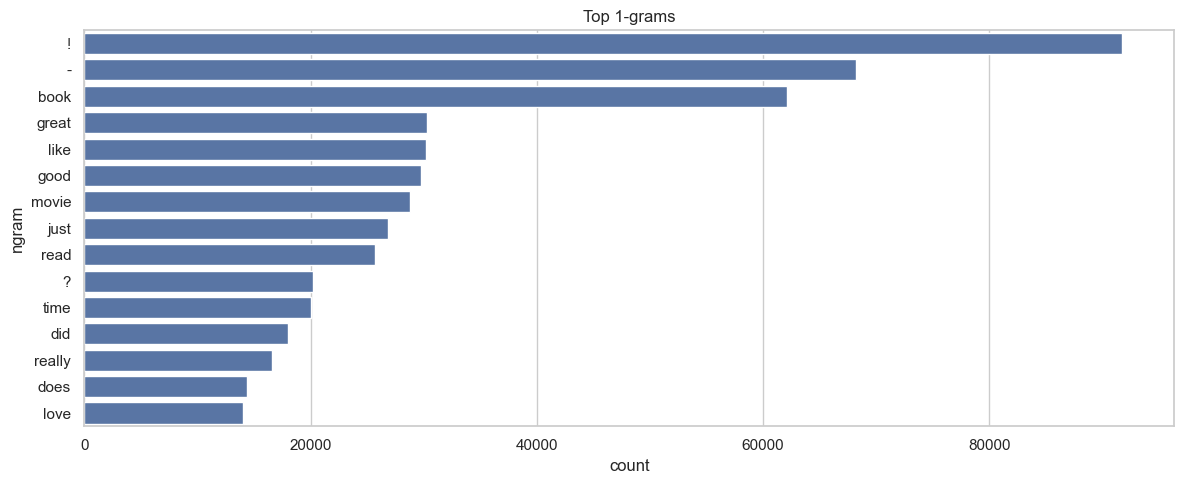

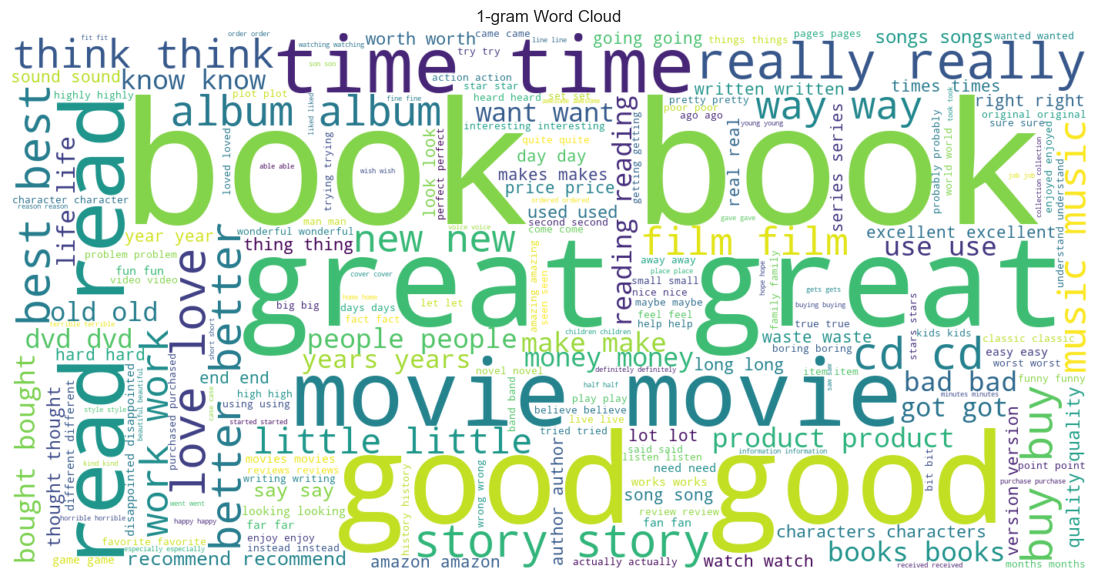

**Top 2-grams**

,ngram,count
0,! !,30407
4609,- -,10576
256512,read book,3885
11334,? ?,3256
346032,waste money,2086
44595,book read,2011
41843,book !,1861
346065,waste time,1787
361249,year old,1719
139914,great book,1667


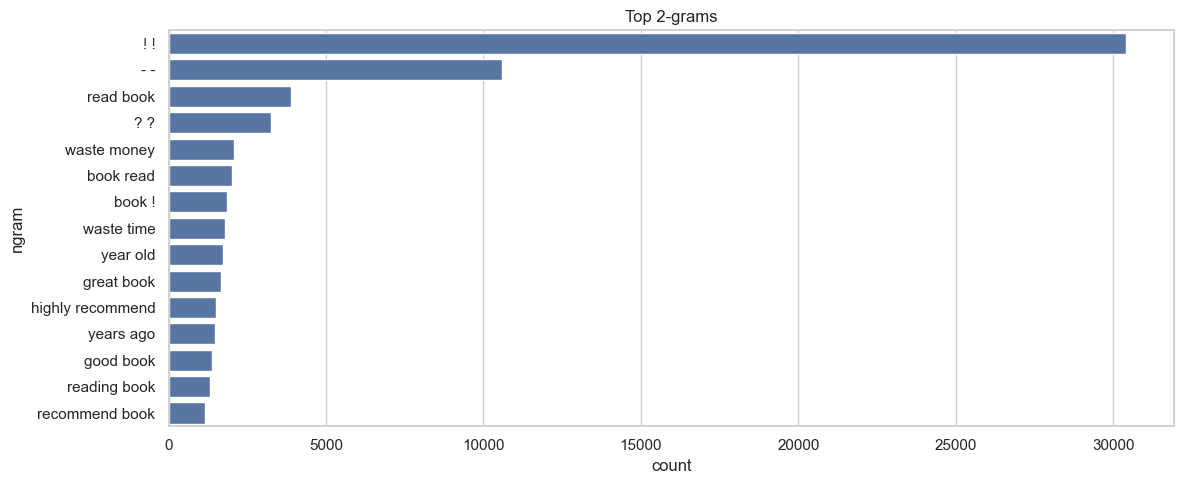

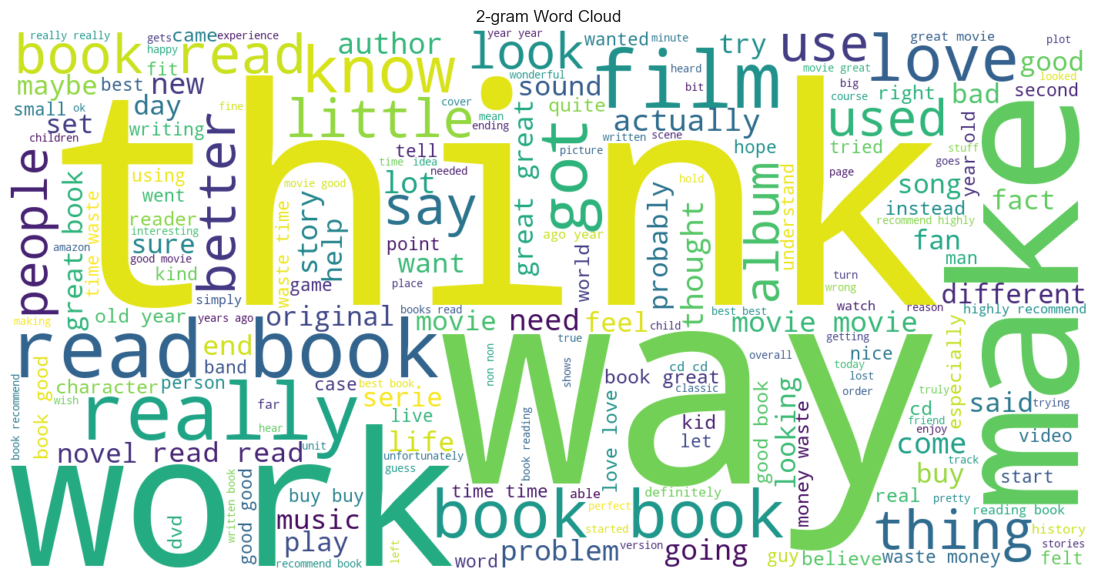

**Top 3-grams**

,ngram,count
0,! ! !,18492
4738,- - -,2071
9281,? ? ?,1792
17677,blu - ray,716
86910,sci - fi,474
8764,/ / /,452
102618,waste time money,416
17829,book ! !,333
106949,year - old,296
102347,waste money !,265


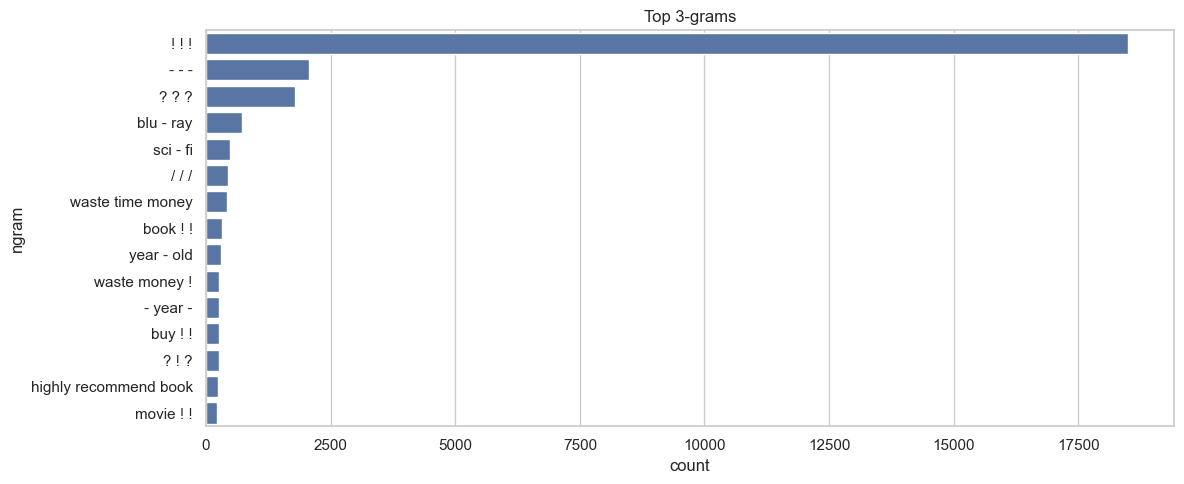

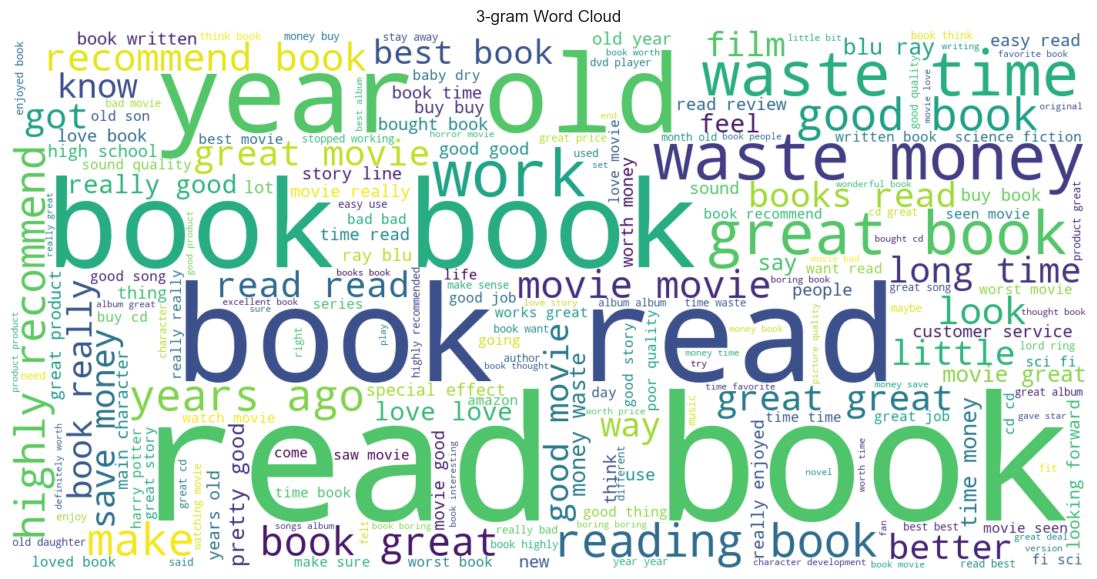

In [32]:
def top_ngrams(text_series: pd.Series, ngram_range=(2, 2), top_k=20):
    vectorizer = CountVectorizer(
        tokenizer=regex_tokenize,
        lowercase=False,
        stop_words="english",
        ngram_range=ngram_range,
        min_df=2,
    )
    matrix = vectorizer.fit_transform(text_series.fillna(""))
    freqs = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    freq_df = pd.DataFrame({"ngram": terms, "count": freqs}).sort_values("count", ascending=False)
    return freq_df.head(top_k), freq_df


analysis_text = df["text"] if not df.empty else pd.Series(demo_reviews)

for n in [(1, 1), (2, 2), (3, 3)]:
    top_df, full_df = top_ngrams(analysis_text, ngram_range=n, top_k=15)
    display(Markdown(f"**Top {n[0]}-grams**"))
    display(top_df)
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_df, x="count", y="ngram")
    plt.title(f"Top {n[0]}-grams")
    plt.tight_layout()
    plt.show()

    weighted_text = " ".join(full_df["ngram"].repeat(np.maximum(full_df["count"].astype(int), 1)))
    if weighted_text.strip():
        wc = WordCloud(width=1400, height=700, background_color="white").generate(weighted_text)
        plt.figure(figsize=(14, 7))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{n[0]}-gram Word Cloud")
        plt.show()

## 13) Section B — Practical Task 3: Zipf’s Law Validation

,token,frequency,rank,log_rank,log_frequency
0,the,412625,1,0.000000,5.615556
1,and,220019,2,0.301030,5.342460
2,is,209617,3,0.477121,5.321427
3,to,193055,4,0.602060,5.285681
4,it,181204,5,0.698970,5.258168
5,of,169162,6,0.778151,5.228303
6,this,154873,7,0.845098,5.189976
7,not,110173,8,0.903090,5.042075
8,in,97348,9,0.954243,4.988327
9,!,91748,10,1.000000,4.962597


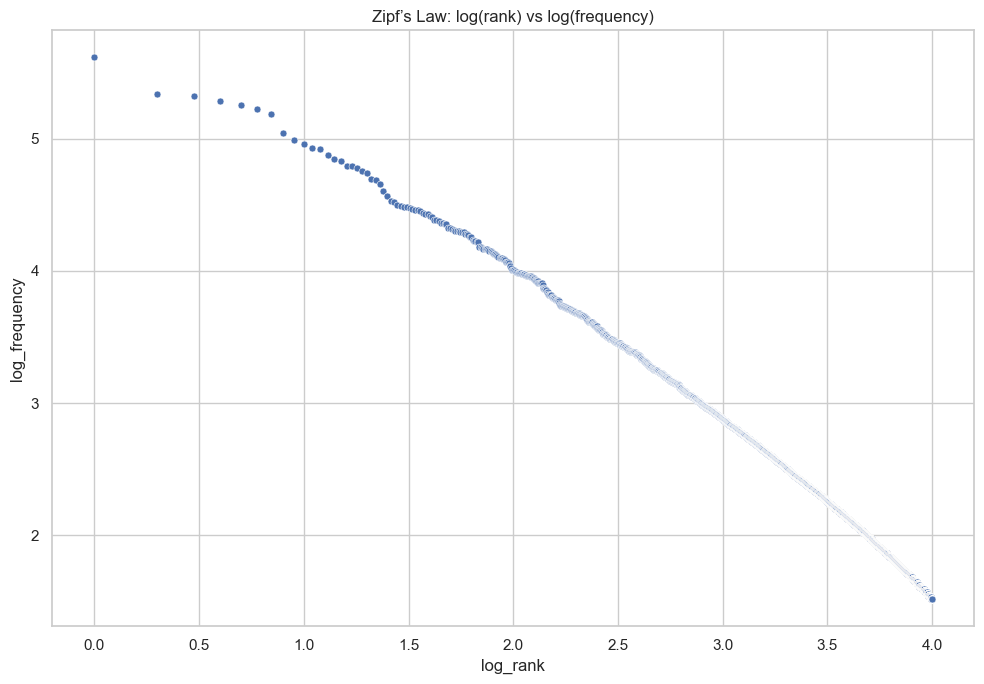

In [33]:
def zipf_analysis(text_series: pd.Series, top_n: int = 20000):
    all_tokens = []
    for txt in text_series.fillna(""):
        all_tokens.extend(regex_tokenize(txt))
    counts = Counter(all_tokens)
    freq_items = counts.most_common(top_n)
    zipf_df = pd.DataFrame(freq_items, columns=["token", "frequency"])
    zipf_df["rank"] = np.arange(1, len(zipf_df) + 1)
    zipf_df["log_rank"] = np.log10(zipf_df["rank"])
    zipf_df["log_frequency"] = np.log10(zipf_df["frequency"])
    return zipf_df


zipf_df = zipf_analysis(analysis_text, top_n=10000)
display(zipf_df.head(10))

plt.figure(figsize=(10, 7))
sns.scatterplot(data=zipf_df, x="log_rank", y="log_frequency", s=25)
plt.title("Zipf’s Law: log(rank) vs log(frequency)")
plt.tight_layout()
plt.show()

fig = go.Figure(data=go.Scatter(
    x=zipf_df["log_rank"],
    y=zipf_df["log_frequency"],
    mode="markers",
    marker=dict(size=5),
))
fig.update_layout(
    title="Zipf’s Law Validation (Interactive)",
    xaxis_title="log10(rank)",
    yaxis_title="log10(frequency)",
    template="plotly_white",
    height=550,
)
fig.show()

## 14) Section B — Practical Task 4: Data Quality Auditor

,label,text,source_file,char_count,word_count,sentence_count,avg_word_length,char_count,token_count,unique_tokens,stopword_count,informative_count,noise_count,stopword_ratio,informative_ratio,noise_ratio,lexical_diversity,symbol_density,emoji_density
0,2,Great CD: My lovely Pat has one of the GREAT v...,test.ft.txt,533,106,10,3.803738,533.0,100.0,74.0,42.0,58.0,21.0,0.420000,0.580000,0.039400,0.740000,0.0,0.0
1,2,One of the best game music soundtracks - for a...,test.ft.txt,816,148,6,4.256579,816.0,142.0,93.0,66.0,76.0,22.0,0.464789,0.535211,0.026961,0.654930,0.0,0.0
2,1,Batteries died within a year ...: I bought thi...,test.ft.txt,335,60,5,4.491525,335.0,52.0,44.0,21.0,31.0,11.0,0.403846,0.596154,0.032836,0.846154,0.0,0.0
3,2,"works fine, but Maha Energy is better: Check o...",test.ft.txt,229,37,3,4.692308,229.0,37.0,28.0,13.0,24.0,10.0,0.351351,0.648649,0.043668,0.756757,0.0,0.0
4,2,Great for the non-audiophile: Reviewed quite a...,test.ft.txt,412,69,4,4.534247,412.0,70.0,58.0,29.0,41.0,13.0,0.414286,0.585714,0.031553,0.828571,0.0,0.0


,stopword_ratio,informative_ratio,noise_ratio,lexical_diversity
label,,,,
1,0.476782,0.523218,0.035486,0.753586
2,0.460732,0.539268,0.034405,0.764264


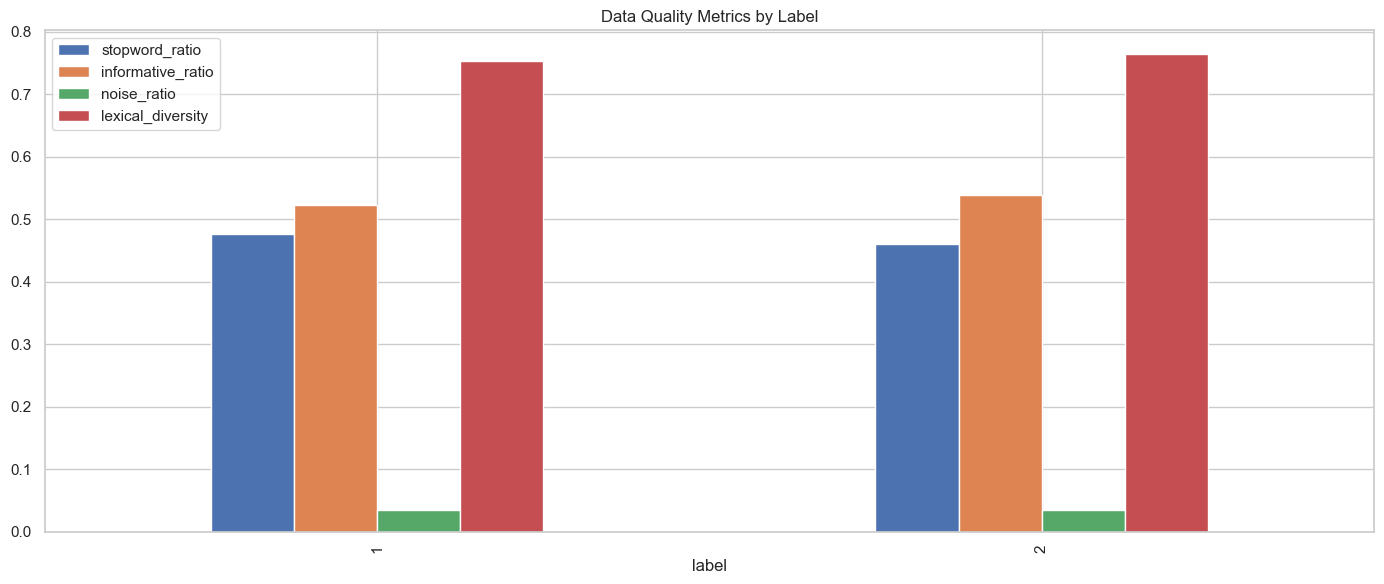

,label,text,source_file,char_count,word_count,sentence_count,avg_word_length,char_count,token_count,unique_tokens,stopword_count,informative_count,noise_count,stopword_ratio,informative_ratio,noise_ratio,lexical_diversity,symbol_density,emoji_density,low_quality_flag
1,2,One of the best game music soundtracks - for a...,test.ft.txt,816,148,6,4.256579,816.0,142.0,93.0,66.0,76.0,22.0,0.464789,0.535211,0.026961,0.654930,0.0,0.0,True
3,2,"works fine, but Maha Energy is better: Check o...",test.ft.txt,229,37,3,4.692308,229.0,37.0,28.0,13.0,24.0,10.0,0.351351,0.648649,0.043668,0.756757,0.0,0.0,True
6,1,"Incorrect Disc: I love the style of this, but ...",test.ft.txt,408,80,7,3.714286,408.0,73.0,53.0,36.0,37.0,17.0,0.493151,0.506849,0.041667,0.726027,0.0,0.0,True
8,2,Unique Weird Orientalia from the 1930's: Exoti...,test.ft.txt,362,62,5,4.333333,362.0,62.0,46.0,30.0,32.0,15.0,0.483871,0.516129,0.041436,0.741935,0.0,0.0,True
9,1,"Not an ""ultimate guide"": Firstly,I enjoyed the...",test.ft.txt,881,148,6,4.733333,881.0,146.0,98.0,74.0,72.0,24.0,0.506849,0.493151,0.027242,0.671233,0.0,0.0,True
11,1,"Not!: If you want to listen to El Duke , then ...",test.ft.txt,148,30,2,3.612903,148.0,30.0,22.0,20.0,10.0,7.0,0.666667,0.333333,0.047297,0.733333,0.0,0.0,True
12,1,A complete Bust: This game requires quicktime ...,test.ft.txt,819,142,13,4.315436,819.0,133.0,77.0,69.0,64.0,35.0,0.518797,0.481203,0.042735,0.578947,0.0,0.0,True
13,2,TRULY MADE A DIFFERENCE!: I have been using th...,test.ft.txt,573,114,10,3.938596,573.0,104.0,68.0,57.0,47.0,11.0,0.548077,0.451923,0.019197,0.653846,0.0,0.0,True
14,1,didn't run off of USB bus power: Was hoping th...,test.ft.txt,152,31,2,3.709677,152.0,30.0,24.0,14.0,16.0,7.0,0.466667,0.533333,0.046053,0.800000,0.0,0.0,True
15,1,"Don't buy!: First of all, the company took my ...",test.ft.txt,728,142,8,3.889655,728.0,133.0,77.0,71.0,62.0,23.0,0.533835,0.466165,0.031593,0.578947,0.0,0.0,True


In [34]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+", flags=re.UNICODE
)


def data_quality_metrics(text: str):
    raw = "" if pd.isna(text) else str(text)
    tokens = regex_tokenize(raw)
    tokens_clean = [t for t in tokens if re.search(r"[a-zA-Z0-9]", t)]
    if not tokens_clean:
        return {
            "char_count": 0, "token_count": 0, "unique_tokens": 0,
            "stopword_count": 0, "informative_count": 0, "noise_count": 0,
            "stopword_ratio": 0, "informative_ratio": 0, "noise_ratio": 0,
            "lexical_diversity": 0, "symbol_density": 0, "emoji_density": 0,
        }

    stop_count = sum(1 for t in tokens_clean if t.lower() in STOP_WORDS)
    informative_count = len(tokens_clean) - stop_count
    noise_count = len(re.findall(r"[^a-zA-Z0-9\s]", raw))
    emoji_count = len(emoji_pattern.findall(raw))
    symbol_count = len(re.findall(r"[$€£%#@&*+/=]", raw))
    return {
        "char_count": len(raw),
        "token_count": len(tokens_clean),
        "unique_tokens": len(set(tokens_clean)),
        "stopword_count": stop_count,
        "informative_count": informative_count,
        "noise_count": noise_count,
        "stopword_ratio": stop_count / max(len(tokens_clean), 1),
        "informative_ratio": informative_count / max(len(tokens_clean), 1),
        "noise_ratio": noise_count / max(len(raw), 1),
        "lexical_diversity": len(set(tokens_clean)) / max(len(tokens_clean), 1),
        "symbol_density": symbol_count / max(len(raw), 1),
        "emoji_density": emoji_count / max(len(raw), 1),
    }


metrics_df = df["text"].apply(data_quality_metrics).apply(pd.Series) if not df.empty else pd.DataFrame([data_quality_metrics(t) for t in demo_reviews])
quality_df = pd.concat([df.reset_index(drop=True), metrics_df.reset_index(drop=True)], axis=1) if not df.empty else metrics_df

display(quality_df.head())

if "label" in quality_df.columns:
    grouped = quality_df.groupby("label")[["stopword_ratio", "informative_ratio", "noise_ratio", "lexical_diversity"]].mean().sort_values("stopword_ratio", ascending=False)
    display(grouped)

    grouped.plot(kind="bar", figsize=(14, 6))
    plt.title("Data Quality Metrics by Label")
    plt.tight_layout()
    plt.show()

quality_df["low_quality_flag"] = (
    (quality_df["noise_ratio"] > quality_df["noise_ratio"].quantile(0.75)) |
    (quality_df["lexical_diversity"] < quality_df["lexical_diversity"].quantile(0.25))
)

display(quality_df.loc[quality_df["low_quality_flag"]].head(10))

## 15) Section C — Mini Project: Automated Feedback Structural Auditor

,count,mean,std,min,25%,50%,75%,max
char_count,100000.0,440.598860,240.379924,101.000000,237.000000,394.000000,609.000000,1015.000000
char_count,100000.0,440.598860,240.379924,101.000000,237.000000,394.000000,609.000000,1015.000000
word_count,100000.0,80.056530,43.285440,12.000000,44.000000,72.000000,111.000000,241.000000
token_count,100000.0,77.271020,42.159167,4.000000,42.000000,69.000000,107.000000,240.000000
unique_tokens,100000.0,55.754100,26.127445,2.000000,34.000000,52.000000,75.000000,135.000000
stopword_ratio,100000.0,0.468616,0.069687,0.000000,0.430769,0.473684,0.513514,0.950495
informative_ratio,100000.0,0.531384,0.069687,0.049505,0.486486,0.526316,0.569231,1.000000
noise_ratio,100000.0,0.034936,0.016130,0.001008,0.025105,0.032193,0.041176,0.820789
lexical_diversity,100000.0,0.759019,0.093969,0.089109,0.691057,0.753086,0.823529,1.000000
symbol_density,100000.0,0.000629,0.003235,0.000000,0.000000,0.000000,0.000000,0.688312


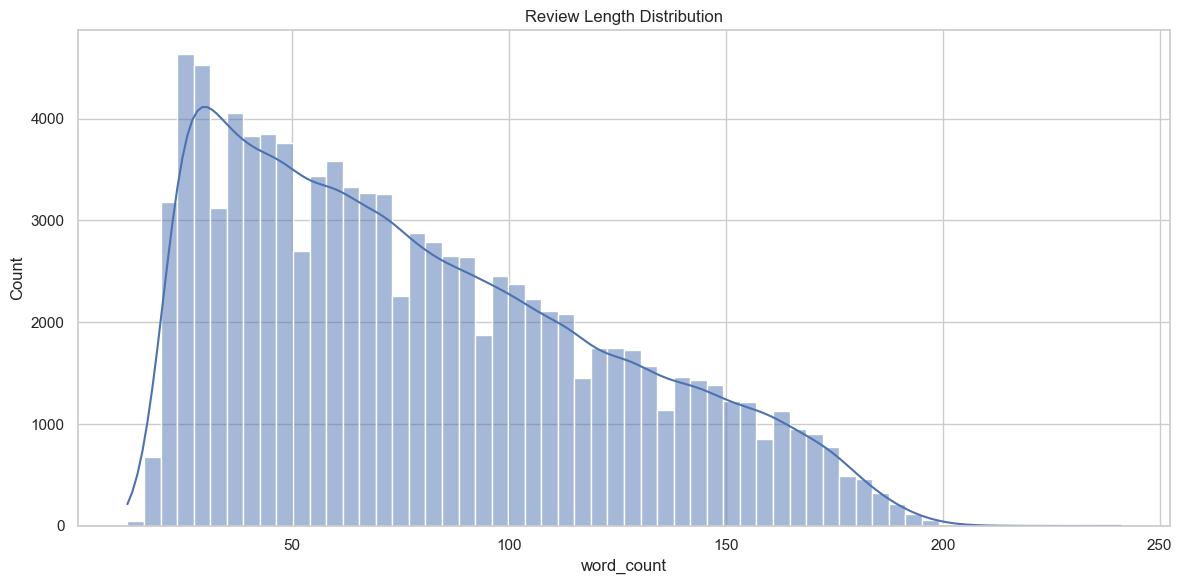

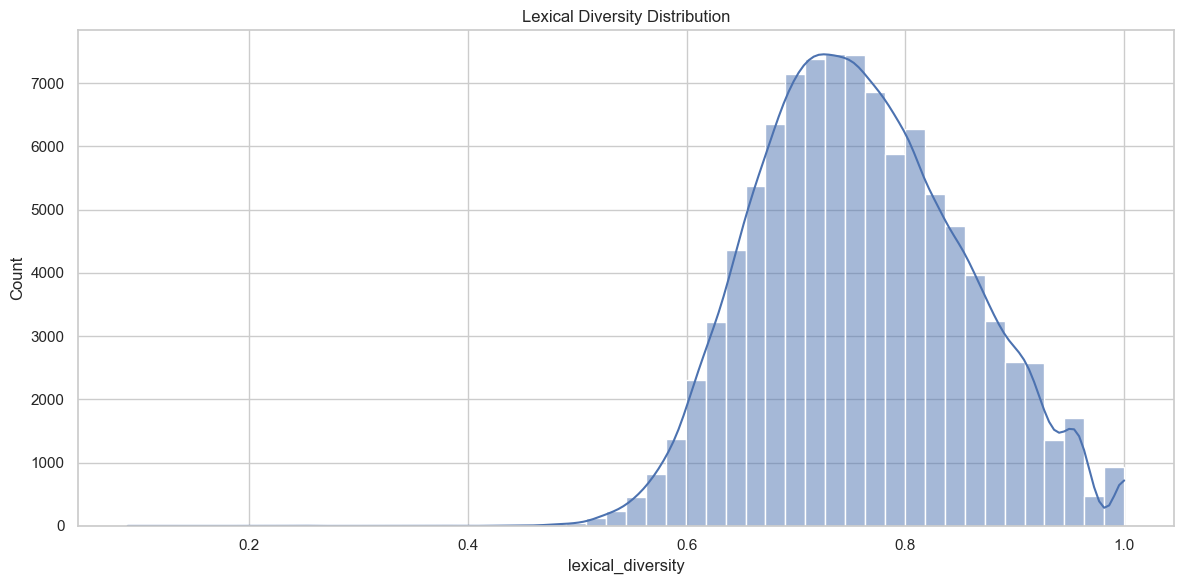

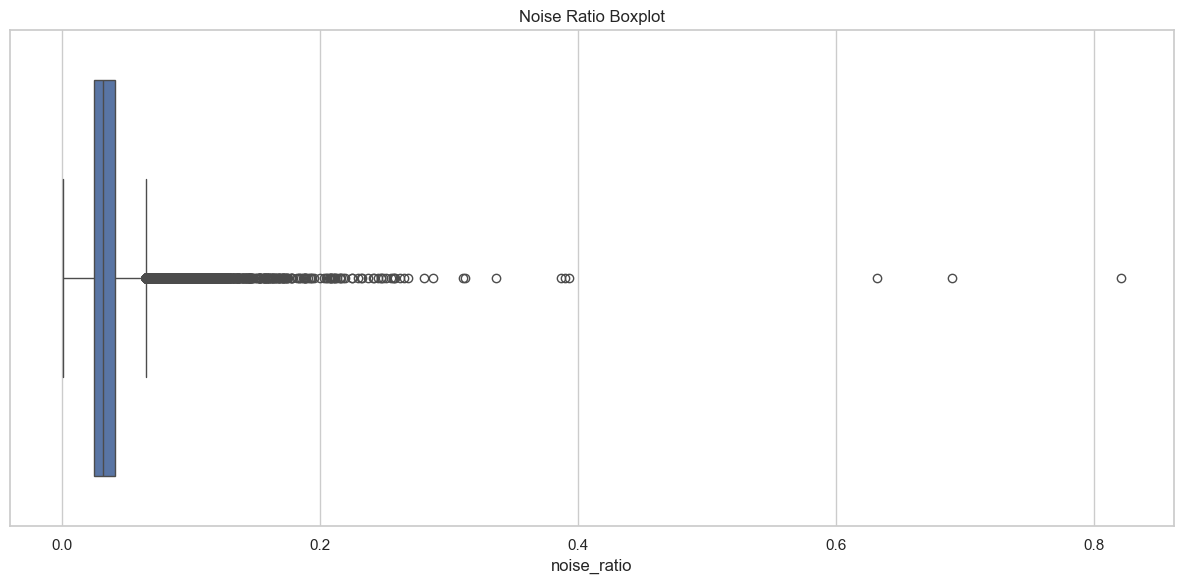

In [35]:
# Structural profiling summary
profile_cols = [c for c in [
    "char_count", "word_count", "token_count", "unique_tokens", "stopword_ratio",
    "informative_ratio", "noise_ratio", "lexical_diversity", "symbol_density", "emoji_density"
] if c in quality_df.columns]

profiling_summary = quality_df[profile_cols].describe().T if profile_cols else pd.DataFrame()
display(profiling_summary)

plt.figure(figsize=(12, 6))
if "word_count" in quality_df.columns:
    sns.histplot(quality_df["word_count"], bins=60, kde=True)
    plt.title("Review Length Distribution")
    plt.tight_layout()
    plt.show()

if "lexical_diversity" in quality_df.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(quality_df["lexical_diversity"], bins=50, kde=True)
    plt.title("Lexical Diversity Distribution")
    plt.tight_layout()
    plt.show()

if "noise_ratio" in quality_df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=quality_df["noise_ratio"])
    plt.title("Noise Ratio Boxplot")
    plt.tight_layout()
    plt.show()

In [36]:
# Regex cleaning pipeline demonstration
def regex_clean_pipeline(text: str):
    original = str(text)
    steps = {
        "original": original,
        "html_removed": BeautifulSoup(original, "html.parser").get_text(" "),
        "url_removed": re.sub(r"http\S+|www\.\S+", " ", original),
    }
    t = steps["url_removed"]
    t = expand_contractions(t)
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\$\€\£\%\-\+\/ ]", " ", t)
    t = t.lower().strip()
    steps["final_clean"] = t
    return steps


example_text = demo_reviews[0]
pipeline_steps = regex_clean_pipeline(example_text)
for k, v in pipeline_steps.items():
    display(Markdown(f"**{k}:** {v}"))

**original:** Best... to good: At first I didn't mlike cats a lot. But when I read this book I turned into a cat lover. This was my favorite book until I read the second and third book. Those are way better. If this is going to be your first time reading this book. READ IT!!Here is a super short summary of what happens: A house cat named Rusty turns into Firepaw because he joins Thunderclan (from the forest) and he turns into an apprentice and has bad luck and very good luck.

**html_removed:** Best... to good: At first I didn't mlike cats a lot. But when I read this book I turned into a cat lover. This was my favorite book until I read the second and third book. Those are way better. If this is going to be your first time reading this book. READ IT!!Here is a super short summary of what happens: A house cat named Rusty turns into Firepaw because he joins Thunderclan (from the forest) and he turns into an apprentice and has bad luck and very good luck.

**url_removed:** Best... to good: At first I didn't mlike cats a lot. But when I read this book I turned into a cat lover. This was my favorite book until I read the second and third book. Those are way better. If this is going to be your first time reading this book. READ IT!!Here is a super short summary of what happens: A house cat named Rusty turns into Firepaw because he joins Thunderclan (from the forest) and he turns into an apprentice and has bad luck and very good luck.

**final_clean:** best... to good  at first i did not mlike cats a lot. but when i read this book i turned into a cat lover. this was my favorite book until i read the second and third book. those are way better. if this is going to be your first time reading this book. read it!!here is a super short summary of what happens  a house cat named rusty turns into firepaw because he joins thunderclan  from the forest  and he turns into an apprentice and has bad luck and very good luck.

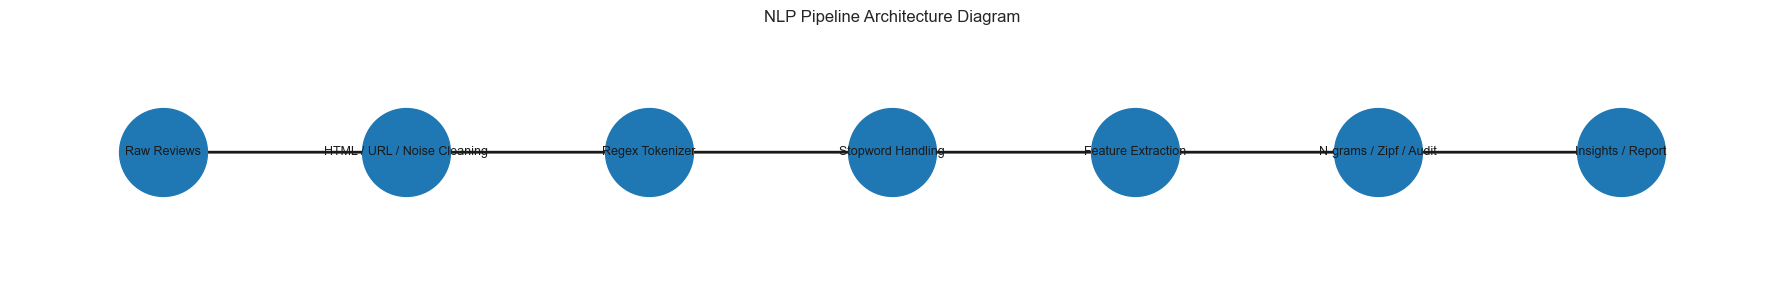

In [37]:
# Architecture diagram using NetworkX
G = nx.DiGraph()
nodes = [
    "Raw Reviews", "HTML / URL / Noise Cleaning", "Regex Tokenizer",
    "Stopword Handling", "Feature Extraction", "N-grams / Zipf / Audit",
    "Insights / Report"
]
edges = list(zip(nodes[:-1], nodes[1:]))

G.add_nodes_from(nodes)
G.add_edges_from(edges)

pos = {
    "Raw Reviews": (0, 0),
    "HTML / URL / Noise Cleaning": (1.7, 0),
    "Regex Tokenizer": (3.4, 0),
    "Stopword Handling": (5.1, 0),
    "Feature Extraction": (6.8, 0),
    "N-grams / Zipf / Audit": (8.5, 0),
    "Insights / Report": (10.2, 0),
}

plt.figure(figsize=(18, 3))
nx.draw_networkx_nodes(G, pos, node_size=4000)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=18, width=2)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.axis("off")
plt.title("NLP Pipeline Architecture Diagram")
plt.tight_layout()
plt.show()

## 16) Final Insights

This notebook demonstrates a complete NLP workflow:
- text is cleaned and tokenized with domain-aware regex,
- frequent words and n-grams are extracted,
- Zipf’s Law is validated on the corpus,
- and review quality is audited with reusable metrics.

The final pipeline is suitable for submission, portfolio use, and further experimentation.

## Conclusion

This notebook is built for **one-click execution** through **Run All**.  
It includes the assessment theory, the implementation tasks, and a structural mini-project in a single reproducible workflow.